In [ ]:
from ccd_simulation import *

In [22]:
import hist
from hist import Hist
import numpy as np

lower_exp0 = 1e-7
upper_exp0 = 1e-5

lower_exp4 = 1e-7
upper_exp4 = 5e-5



lower_exp6 = 1e-7
upper_exp6 = 6e-5


lower_exp10 = 1e-5
upper_exp10 = 2e-4


lower_exp20 = 1e-4
upper_exp20 = 6e-4



# lower = np.min(densities_exp)
histograms = {
    0: Hist(hist.axis.Regular(50, lower_exp0, upper_exp0, name="1e Densities Exp 0h")),
    4: Hist(hist.axis.Regular(50, lower_exp4, upper_exp4, name="1e Densities Exp 4h")),
    6: Hist(hist.axis.Regular(50, lower_exp6, upper_exp6, name="1e Densities Exp 6h")),
    10: Hist(hist.axis.Regular(50, lower_exp10, upper_exp10, name="1e Densities Exp 10h")),
    20: Hist(hist.axis.Regular(50, lower_exp20, upper_exp20, name="1e Densities Exp 20h")),

}

histograms_no_traps = {
    0: Hist(hist.axis.Regular(50, lower_exp0, upper_exp0, name="1e Densities Exp 0h")),
    4: Hist(hist.axis.Regular(50, lower_exp4, upper_exp4, name="1e Densities Exp 4h")),
    6: Hist(hist.axis.Regular(50, lower_exp6, upper_exp6, name="1e Densities Exp 6h")),
    10: Hist(hist.axis.Regular(50, lower_exp10, upper_exp10, name="1e Densities Exp 10h")),
    20: Hist(hist.axis.Regular(50, lower_exp20, upper_exp20, name="1e Densities Exp 20h")),

}

In [23]:
import pickle
mean_traps = {

}
mean_notraps = {
}

mean_traps_err = {

}
mean_notraps_err = {

}
for i in range(3):
    with open(f'ccd_traps_run{i}.pkl','rb') as f:
        ccd_run = pickle.load(f)

        densities = np.array(ccd_run.single_e_counts_masked) / np.array(ccd_run.unmasked_pixels)
        densities_notraps = np.array(ccd_run.single_e_counts_masked_no_traps) / np.array(ccd_run.unmasked_pixels_no_traps)

        unique_exposures = np.unique( np.sort(np.array(ccd_run.exposures)))
        for e in range(len(unique_exposures)):
            exp = unique_exposures[e]
            expkey = int(exp / 3600)
            print(expkey)
            exp_indices = np.array(ccd_run.exposures) == exp

            densities_exp = densities[exp_indices]

            print("Max: ", np.max(densities_exp))
            print("Min: ", np.min(densities_exp))

            mean_traps[expkey] = np.sum(np.array(ccd_run.single_e_counts_masked)[exp_indices]) / np.sum(np.array(ccd_run.unmasked_pixels)[exp_indices])
            mean_traps_err[expkey] = np.sqrt(np.sum(np.array(ccd_run.single_e_counts_masked)[exp_indices])) / np.sum(np.array(ccd_run.unmasked_pixels)[exp_indices])

            densities_exp_notraps = densities_notraps[exp_indices]
            mean_notraps[expkey] = np.sum(np.array(ccd_run.single_e_counts_masked_no_traps)[exp_indices]) / np.sum(np.array(ccd_run.unmasked_pixels_no_traps)[exp_indices])
            mean_notraps_err[expkey] = np.sqrt(np.sum(np.array(ccd_run.single_e_counts_masked_no_traps)[exp_indices]))/ np.sum(np.array(ccd_run.unmasked_pixels_no_traps)[exp_indices])

            histograms[expkey].fill(densities_exp)
            histograms_no_traps[expkey].fill(densities_exp_notraps)
        del ccd_run







0
Max:  7.62939453125e-06
Min:  6.357828776041666e-07
4
Max:  3.213811294523189e-05
Min:  8.671844996964854e-06
6
Max:  4.915918390580066e-05
Min:  1.543095913330916e-05
10
Max:  0.0001110751830889268
Min:  4.3254806198806955e-05
20
Max:  0.0004851189754287239
Min:  0.00022019208245490748
0
Max:  8.265177408854166e-06
Min:  1.2715657552083333e-06
4
Max:  2.7291116523242752e-05
Min:  8.459298554963822e-06
6
Max:  4.659266433797472e-05
Min:  1.5608381254780066e-05
10
Max:  0.00012173084470712188
Min:  3.272453576609956e-05
20
Max:  0.0004993246314280044
Min:  0.00022215610433402757
0
Max:  9.5367431640625e-06
Min:  6.357828776041666e-07
4
Max:  3.214204567495525e-05
Min:  8.155875084617203e-06
6
Max:  4.968113742705906e-05
Min:  9.842059549381304e-06
10
Max:  0.00011232360920174541
Min:  4.214664349878445e-05
20
Max:  0.00046819851617085646
Min:  0.00018714040753087816


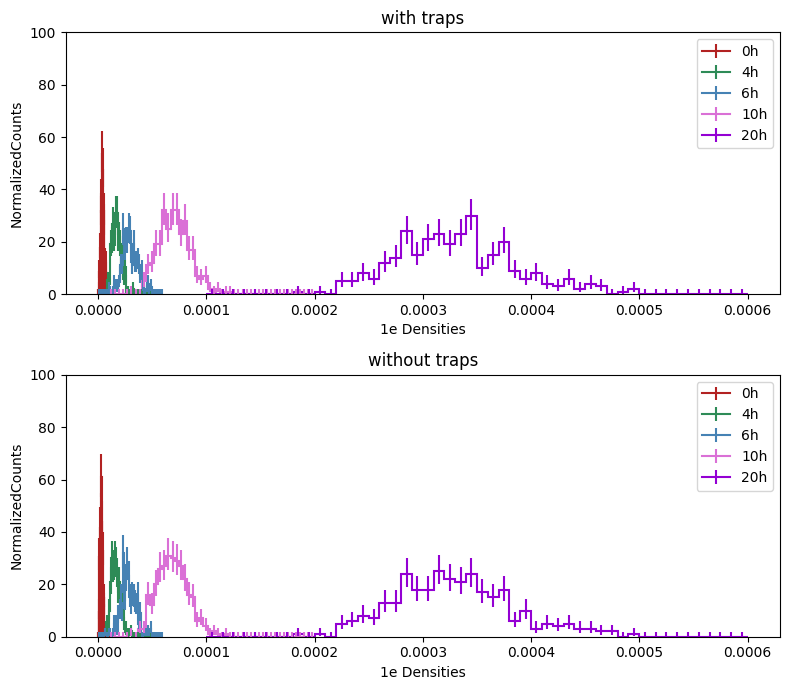

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [24]:
import matplotlib.pyplot as plt
colorlist = ['firebrick','seagreen','steelblue','orchid','darkviolet']
fig, ax = plt.subplots(2,figsize=(8,7))
for i in range(2):
    if i == 0:
        hists = histograms
        t = 'with'
    elif i == 1:
        hists = histograms_no_traps
        t = 'without'
    for j,h in enumerate([0,4,6,10,20]):
        color = colorlist[j]
        plothist = hists[h] #/ np.sum(hists[h].values())

        plothist.plot1d(ax=ax[i],color=color,label=f'{h}h')
    # hists[4].plot1d(ax=ax[i],color='seagreen',label='4h')
    # hists[6].plot1d(ax=ax[i],color='steelblue',label='6h')
    # hists[10].plot1d(ax=ax[i],color='orchid',label='10h')
    # hists[20].plot1d(ax=ax[i],color='darkviolet',label='20h')

    ax[i].set_ylim(0,100)
    ax[i].set_title(f"{t} traps")
    ax[i].set_ylabel("NormalizedCounts")
    ax[i].set_xlabel("1e Densities")
    ax[i].legend()
plt.tight_layout()
plt.show()
plt.close()

plt.figure()

# histograms[20]

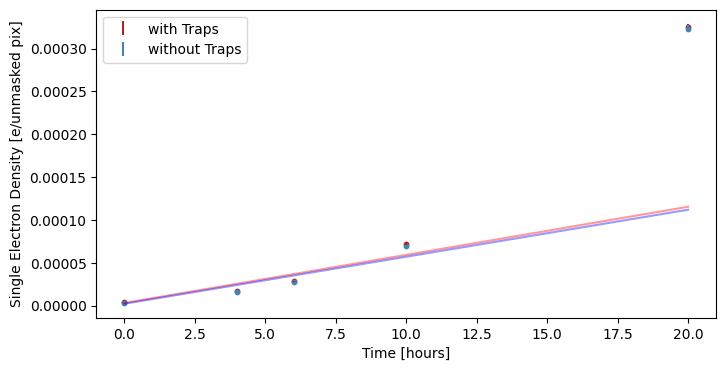

With Traps
exposure independent: 3.081314856929458e-06
exposure dependent: 5.6113836297400755e-06
Without Traps
exposure independent: 2.1697489434714924e-06
exposure dependent: 5.485884468109348e-06
True Parameters
exposure independent: 3.10625e-06
exposure dependent: 4.36e-05


In [30]:
unique_exposures_h = unique_exposures / 3600
unique_exposures_h = unique_exposures_h.astype(int)

average_densities = np.array([mean_traps[h] for h in unique_exposures_h])   #np.array([np.mean(mean_traps[h]) for h in unique_exposures_h])
average_densities_notraps =  np.array([mean_notraps[h] for h in unique_exposures_h])     #np.array([np.mean(mean_notraps[h]) for h in unique_exposures_h])

average_density_err = np.array([mean_traps_err[h] for h in unique_exposures_h])   #np.array([np.mean(mean_traps[h]) for h in unique_exposures_h])
average_density_err_notraps =  np.array([mean_notraps_err[h] for h in unique_exposures_h])     #np.array([np.mean(mean_notraps[h]) for h in unique_exposures_h])



from scipy.optimize import curve_fit


def line(x,m,b):
    y = m*x + b
    return y


# days = unique_exposures_h.reshape((-1, 1))
popt, pcov = curve_fit(line, unique_exposures_h, average_densities, sigma=average_density_err, absolute_sigma=True)
exp_dep, exp_indep = popt



popt, pcov = curve_fit(line, unique_exposures_h, average_densities_notraps, sigma=average_density_err_notraps, absolute_sigma=True)

# model_notraps = LinearRegression().fit(days, average_densities_notraps)

# exp_indep_notraps = model_notraps.intercept_
# exp_dep_notraps = model_notraps.coef_[0]

exp_dep_notraps, exp_indep_notraps = popt


hours = np.linspace(0,20,20)




fit_no_traps = line(hours,exp_dep_notraps,exp_indep_notraps)
fit_traps = line(hours,exp_dep,exp_indep)


plt.figure(figsize=(8,4))
plt.scatter(unique_exposures_h,average_densities,color='firebrick',s=10)
plt.scatter(unique_exposures_h,average_densities_notraps,color='steelblue',s=10)

plt.plot(hours,fit_traps,color='red',alpha=0.4)
plt.plot(hours,fit_no_traps,color='blue',alpha=0.4)

plt.errorbar(unique_exposures_h,average_densities,yerr=average_density_err,label='with Traps',color='firebrick',ls='None')
plt.errorbar(unique_exposures_h,average_densities_notraps,yerr=average_density_err_notraps,label='without Traps',color='steelblue',ls='None')
plt.ylabel("Single Electron Density [e/unmasked pix]")
plt.xlabel("Time [hours]")
plt.legend()
plt.show()
plt.close()

print("With Traps")
print(f'exposure independent: {exp_indep}')
print(f'exposure dependent: {exp_dep}')


print("Without Traps")
print(f'exposure independent: {exp_indep_notraps}')
print(f'exposure dependent: {exp_dep_notraps}')

print("True Parameters")
print(f'exposure independent: {3.10625e-06}')
print(f'exposure dependent: {4.36e-05}')




In [28]:
average_densities,average_density_err

(array([4.54584757e-06, 1.71400415e-05, 2.85593183e-05, 7.18146882e-05,
        3.24772580e-04]),
 array([1.70005060e-07, 4.12564137e-07, 6.04506175e-07, 1.19277705e-06,
        4.15318354e-06]))

In [29]:
average_densities_notraps,average_density_err_notraps

(array([3.22977702e-06, 1.60973391e-05, 2.70878484e-05, 6.98930262e-05,
        3.22966812e-04]),
 array([1.43298183e-07, 3.99818223e-07, 5.88727172e-07, 1.17671030e-06,
        4.14162139e-06]))

In [4]:

from utils import *
from astropy.time import Time
#use a snolab image and assume this time is valid for pixel times

def pixel_time(nsamp, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG):		# Time to read 1 pixel
  return 5*int(delayH)+int(delayRG)+(int(delayIped)+int(delaySW)+int(delayIsig)+int(delayOG)+int(delayRG))*int(nsamp)

def pixel_time_vertical(nsamp,ncol, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG,delayDG):		# Time to read 1 pixel
  pixel_time_hor=pixel_time(nsamp, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG)
  return (pixel_time_hor+(int(delaySW)+int(delayDG)))*int(ncol)


snolab_dir = '/data/analyses/snolab_run1/'
file = 'proc_corr_proc_skp_sensei_2023-02-14_135K_run7_commissioning_NROW520_NBINROW1_NCOL3200_NBINCOL1_EXPOSURE72000_CLEAR10800_5_83.fits'
with fits.open(snolab_dir +file) as hdul:
    q = hdul[0]
    header = q.header
    print(list(header.keys()))
    nrow=header['NROW']
    ncol=header['NCOL']
    exposure=header['EXPOSURE']
    nsamp=header['NSAMP']
    delayH=header['HIERARCH DELAY_H_OVERLAP']
    delayRG=header['HIERARCH DELAY_RG_WIDTH']
    delayIped=header['HIERARCH DELAY_INTEG_PED']
    delaySW=header['HIERARCH DELAY_SWHIGH']
    delayIsig=header['HIERARCH DELAY_INTEG_SIG']
    delayOG=header['HIERARCH DELAY_OG_LOW']
    delayDG=header['HIERARCH DELAY_DG_LOW']


    
#     print(list(q.header.keys()))
#     print(q.header['DATESTART'])
#     print(q.header['EXPOSURE'])

#     dte_start = q.header['DATESTART']
#     dte_end = q.header['DATEEND']
#     t = Time([dte_start,dte_end], format='isot')
#     readout_time = t.jd[1] - t.jd[0]
#     print(readout_time * 24 * 3600)
#     readout_time =readout_time * 24 * 3600
# # singleReadTime = smask.readout_time - exp
# # seconds_per_row = (singleReadTime)/nRow
# # seconds_per_pixel = seconds_per_row/nCol

# singleReadTime = readout_time - 72000

# seconds_per_row = (singleReadTime)/nRow
# seconds_per_pixel = seconds_per_row/nCol
tpix=pixel_time(nsamp, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG) / 15e6
tpix_vertical=pixel_time_vertical(nsamp,ncol, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG,delayDG)/15e6

(tpix_vertical * 520)/ 3600

['SIMPLE', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2', 'EXTEND', 'COMMENT', 'COMMENT', 'CCDNCOL', 'CCDNPRES', 'CCDNROW', 'EXPOSURE', 'NBINCOL', 'NBINROW', 'NCOL', 'NROW', 'NSAMP', 'SKIPCOL', 'SKIPROW', 'TOG_VDD', 'TOG_VR', 'DELAY_H_OVERLAP', 'DELAY_INTEG_PED', 'DELAY_INTEG_SIG', 'DELAY_RG_WIDTH', 'DELAY_SWHIGH', 'DELAY_V_OVERLAP', 'DELAY_DG_LOW', 'DELAY_EXPOSE', 'DELAY_OG_LOW', 'V1AH', 'V1AL', 'V1BH', 'V1BL', 'V2CH', 'V2CL', 'V3AH', 'V3AL', 'V3BH', 'V3BL', 'H1AH', 'H1AL', 'H1BH', 'H1BL', 'H2CH', 'H2CL', 'H3AH', 'H3AL', 'H3BH', 'H3BL', 'SWAH', 'SWAL', 'SWBH', 'SWBL', 'RGAH', 'RGAL', 'RGBH', 'RGBL', 'OGAH', 'OGAL', 'OGBH', 'OGBL', 'DGAH', 'DGAL', 'DGBH', 'DGBL', 'TGAH', 'TGAL', 'TGBH', 'TGBL', 'LDAC_N', 'CLR_N', 'RESET_N', 'SW_EN', 'VDRAIN', 'VDD', 'VR', 'VSUB', 'VDD_SW', 'VDRAIN_SW', 'VSUB_SW', 'VSUB_LOAD_SW', 'VSUB_RDIV_SW', 'VR_SW', 'P15V_SW', 'M15V_SW', 'PACKSOURCE', 'PACKSTART', 'TESTPTRNA', 'TESTPTRNB', 'TESTPTRNC', 'TESTPTRND', 'CALSTART', 'CALADONE', 'CALBDONE', 'CALCDONE', 'CALDDONE'

7.091783111111111